# Library Import

In [501]:
import cv2
import matplotlib.pyplot as plt
import warnings

import pandas as pd
from tensorflow import keras
from keras.src.layers import Rescaling
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import os
from tqdm import tqdm
from sklearn.utils import shuffle

warnings.filterwarnings('ignore')

Sequential = keras.models.Sequential
Conv2D = keras.layers.Conv2D
Flatten = keras.layers.Flatten
Dropout = keras.layers.Dropout
MaxPooling2D = keras.layers.MaxPooling2D
Dense = keras.layers.Dense
Input = keras.layers.Input
EarlyStopping = keras.callbacks.EarlyStopping
ReduceLROnPlateau = keras.callbacks.ReduceLROnPlateau
Layers = keras.layers
ImageDataGenerator = keras.preprocessing.image.ImageDataGenerator
BatchNormalization = keras.layers.BatchNormalization
CSVLogger = keras.callbacks.CSVLogger
ModelCheckpoint = keras.callbacks.ModelCheckpoint

# PATH

In [502]:
train_path = 'dataset/training/'
PLOT_SAVE_DIR = 'output/plot/v1/'
LOG_DIR = 'output/log/v1/'
MODEL_SAVE_PATH = 'output/model/v1/cnn_model_v1.keras'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

LABEL_MAPPING = {
    'alcohol': 0,
    'blood': 1,
    'sexual': 2,
    'traffic_accident': 3
}

class_names = ['alcohol', 'blood', 'sexual', 'traffic_accident']
nb_classes = len(class_names)

In [503]:
print(f"class_names: {class_names}")
print(f"class length: [{nb_classes}]")

class_names: ['alcohol', 'blood', 'sexual', 'traffic_accident']
class length: [4]


# Function to load data

In [504]:
def load_data(dataset):
    images = []
    labels = []

    if isinstance(dataset, str):
        dataset = [dataset]

    for dataset_path in dataset:
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset directory {dataset_path} not found.")

        for folder in os.listdir(dataset_path):
            if folder in LABEL_MAPPING:
                label = LABEL_MAPPING[folder]
            else:
                continue

            folder_path = os.path.join(dataset_path, folder)

            if not os.path.isdir(folder_path):
                continue

            for file in tqdm(os.listdir(folder_path)):
                img_path = os.path.join(folder_path, file)

                if not os.path.isfile(img_path):
                    continue

                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int')

    images /= 255.0

    return images, labels

# Execute images and labels

In [505]:
images, labels = load_data(train_path)

100%|██████████| 500/500 [00:01<00:00, 381.35it/s]


# Split data into training and testing sets (80% train, 20% test)

In [506]:
images, labels = shuffle(images, labels, random_state=10)

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2)
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size=0.5)

In [507]:
n_train = train_labels.shape[0]
n_val = val_labels.shape[0]
n_test = test_labels.shape[0]

print("Number of training examples: {}".format(n_train))
print("Number of validation examples: {}".format(n_val))
print("Number of testing examples: {}".format(n_test))

print("Training images are of shape: {}".format(train_images.shape))
print("Training labels are of shape: {}".format(train_labels.shape))
print("Validation images are of shape: {}".format(val_images.shape))
print("Validation labels are of shape: {}".format(val_labels.shape))
print("Test images are of shape: {}".format(test_images.shape))
print("Test labels are of shape: {}".format(test_labels.shape))

Number of training examples: 1600
Number of validation examples: 200
Number of testing examples: 200
Training images are of shape: (1600, 224, 224)
Training labels are of shape: (1600,)
Validation images are of shape: (200, 224, 224)
Validation labels are of shape: (200,)
Test images are of shape: (200, 224, 224)
Test labels are of shape: (200,)


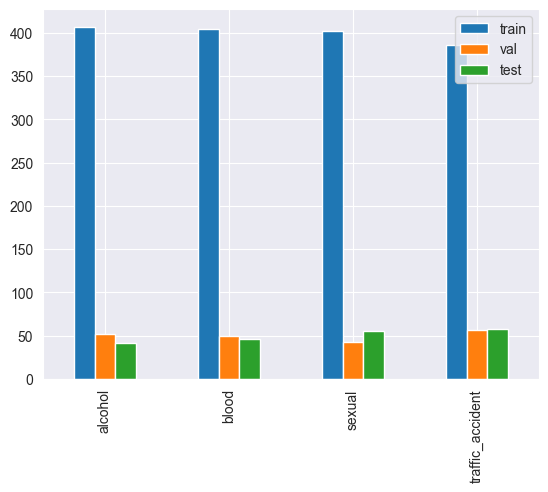

In [508]:
_, train_counts = np.unique(train_labels, return_counts=True)
_, val_counts = np.unique(val_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)

pd.DataFrame({'train': train_counts, "val": val_counts, "test": test_counts}, index=class_names).plot.bar()

plt.show()

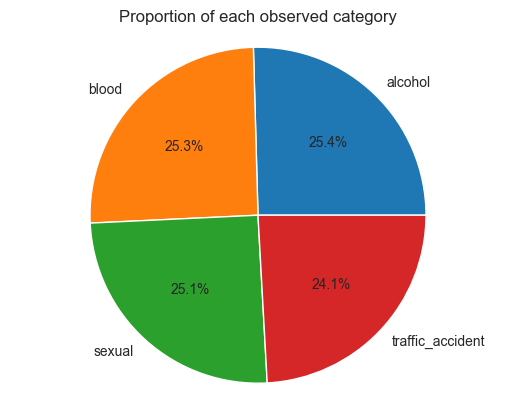

In [509]:
plt.pie(train_counts,
        explode=(0, 0, 0, 0),
        labels=class_names,
        autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each observed category')
plt.show()

# Normalize images

In [510]:
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

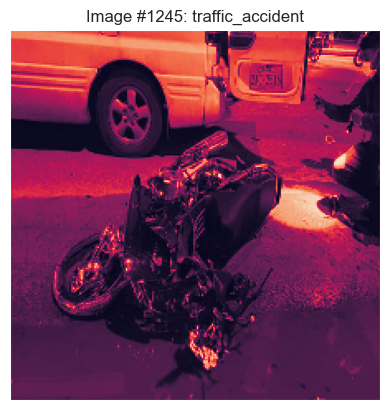

In [511]:
def display_random_image(class_names, images, labels):
    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{}: '.format(index) + class_names[labels[index]])
    plt.show()


display_random_image(class_names, train_images, train_labels)

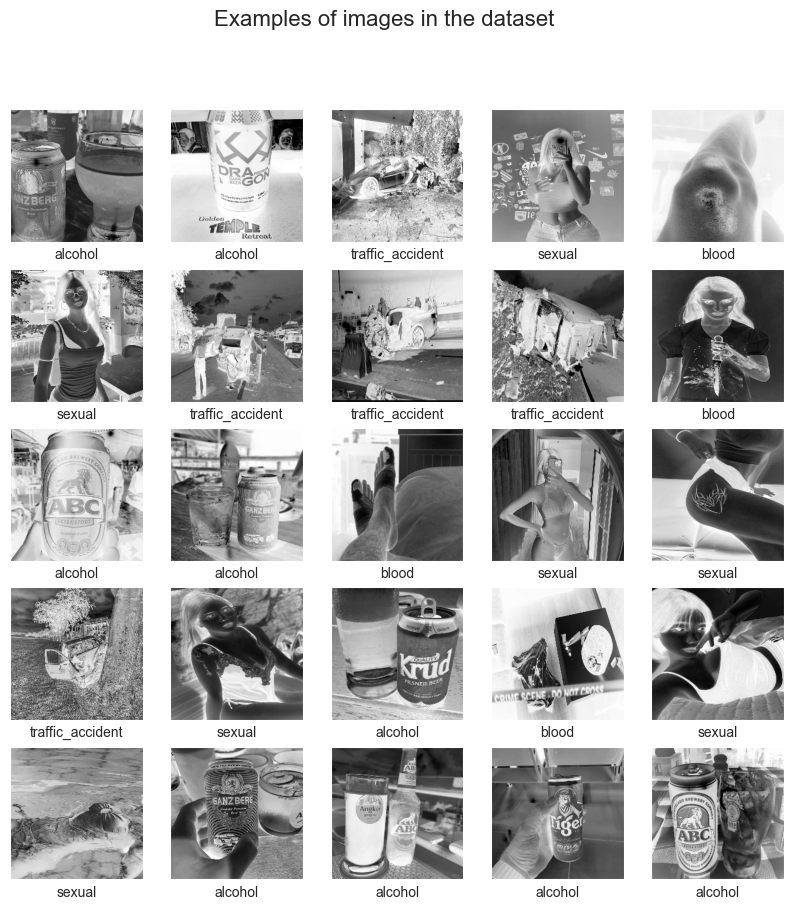

In [512]:
def display_examples(class_names, images, labels):
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle("Examples of images in the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()


display_examples(class_names, train_images, train_labels)

# Model architecture

In [513]:
# Model architecture
model = Sequential()

# Normalization layer
model.add(Rescaling(1. / 255, input_shape=(224, 224, 1)))

# First convolutional block
model.add(Conv2D(32, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Second convolutional block
model.add(Conv2D(64, kernel_size=(5, 5), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Third convolutional block
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Fourth convolutional block
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))

# Flatten
model.add(Flatten())

# Fully connected layers 
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

# Output layer 
model.add(Dense(units=len(class_names), activation='sigmoid'))

# summary
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 220, 220, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 106, 106, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 23, 23, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 23, 23, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 512)            │    15,860,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,349,444 (62.37 MB)

 Trainable params: 16,348,484 (62.36 MB)

 Non-trainable params: 960 (3.75 KB)

# Compile the model

In [514]:
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
csv_logger = CSVLogger(os.path.join(LOG_DIR, 'training_log_v1.csv'))
checkpoint = ModelCheckpoint(filepath=MODEL_SAVE_PATH, save_best_only=True, save_weights_only=False)
early_stop = EarlyStopping(monitor='val_loss', min_delta=0.1, patience=3, verbose=1, mode='min',
                           restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=0.000001)

# Train
history = model.fit(
    train_images,
    train_labels,
    batch_size=32,
    epochs=EPOCHS,
    validation_data=(val_images, val_labels),
    callbacks=[learning_rate_reduction, csv_logger])

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.4296 - loss: 1.3198 - val_accuracy: 0.2600 - val_loss: 1.3933 - learning_rate: 0.0010
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.5740 - loss: 1.0077 - val_accuracy: 0.2600 - val_loss: 1.4230 - learning_rate: 0.0010
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6394 - loss: 0.8948 - val_accuracy: 0.2800 - val_loss: 1.7172 - learning_rate: 0.0010
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6840 - loss: 0.7873 - val_accuracy: 0.2600 - val_loss: 1.8851 - learning_rate: 0.0010
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7572 - loss: 0.6569
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7570 - loss: 0.6572 - val_accuracy: 0.2150 - val_loss: 2.1528 - learning_rate: 0.0010


# Evaluate the model

In [515]:
def plot_accuracy_loss_chart(history):
    epochs = [i for i in range(10)]
    fig, ax = plt.subplots(1, 2)
    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    fig.set_size_inches(20, 10)
    ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
    ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax[0].set_title('Training & Validation Accuracy')
    ax[0].legend()
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")

    ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax[1].set_title('Training & Validation Loss')
    ax[1].legend()
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Training & Validation Loss")
    plt.show()

ValueError: x and y must have same first dimension, but have shapes (10,) and (5,)

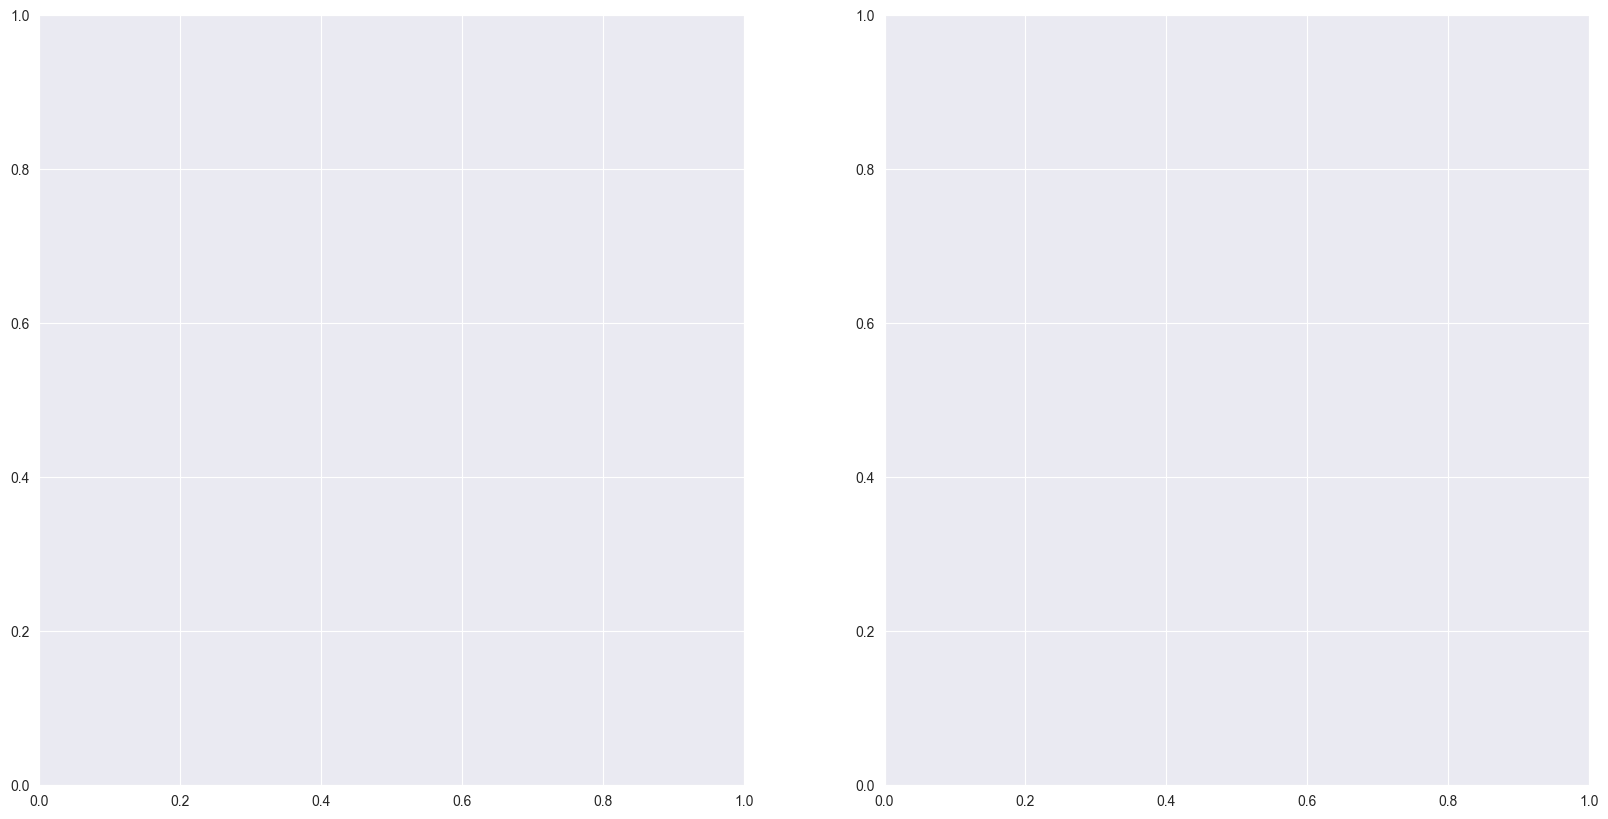

In [516]:
plot_accuracy_loss_chart(history)

In [ ]:
results = model.evaluate(test_images, test_labels)

print("Loss of the model is - ", results[0])
print("Accuracy of the model is - ", results[1] * 100, "%")

# Save the trained model

In [ ]:
model.save(MODEL_SAVE_PATH)

In [ ]:
predictions = model.predict(test_images)
predictions = np.argmax(predictions, axis=1)
predictions[:15]

In [ ]:
print(classification_report(
    test_labels,
    predictions,
    target_names=['alcohol (Class 0)', 'blood (Class 1)', 'sexual (Class 2)', 'traffic_accident (Class 3)']))

In [ ]:
cm = confusion_matrix(test_labels, predictions)
cm = pd.DataFrame(cm, index=['0', '1', '2', '3'], columns=['0', '1', '2', '3'])
cm

In [ ]:
def plot_confusion_matrix(cm):
    plt.figure(figsize=(10, 10))
    sns.heatmap(
        cm,
        cmap='Blues',
        linecolor='black',
        linewidth=1,
        annot=True,
        fmt='',
        xticklabels=class_names,
        yticklabels=class_names)


plot_confusion_matrix(cm)